In [1]:
!pip install langgraph

In [14]:
from langgraph.graph import START,END,StateGraph
import random
from typing import TypedDict,Literal


**Defining the Data Model**

In [15]:
class JourneyState(TypedDict):
   current_location: str

In [16]:
def chennai(state:JourneyState) ->JourneyState:
    print("Starting the journey from Chennai")
    return {"current_location": "Departed from Chennai"}

In [17]:
def trichy(state:JourneyState) ->JourneyState:
    print("Starting the journey from Trichy")
    return {"current_location": "Reached/Visting Trichy"}

In [18]:
def salem(state:JourneyState) ->JourneyState:
    print("Starting the journey from Salem")
    return {"current_location": "Reached/Visting Salem"}

In [19]:
def decide_intermediate_city(state: JourneyState) -> Literal["trichy","salem"]:
    print("Deciding the route.....Last update:{state ['current_location']}")
    if random.random() <0.5:
       print("--> Route Selected:salem")
       return "salem"
    else:
       print("--> Route Selected:trichy")
       return "trichy"

Building the graph using State Graph

In [20]:
builder = StateGraph(JourneyState)

In [21]:
builder.add_node("chennai",chennai)
builder.add_node("salem",salem)
builder.add_node("trichy",trichy)

In [22]:
builder.add_edge(START,"chennai")
builder.add_conditional_edges("chennai",decide_intermediate_city)

In [23]:
builder.add_edge("trichy",END)
builder.add_edge("salem",END)

In [25]:
graph = builder.compile()

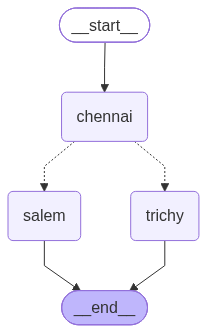

In [27]:
from IPython.display import Image,display
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
graph.invoke({"current_location":"chennai"})

Starting the journey from Chennai
Deciding the route.....Last update:{state ['current_location']}
--> Route Selected:salem
Starting the journey from Salem


{'current_location': 'Reached/Visting Salem'}